# 1. Normalization and Scaling on Wine dataset

In [41]:
import pandas as pd
from sklearn.preprocessing import Normalizer, StandardScaler

In [23]:

wine_csv_url = 'https://raw.githubusercontent.com/rasbt/pattern_classification/master/data/wine_data.csv'

wine_input_df = pd.read_csv(wine_csv_url, usecols=[0,1,2], header=None)
wine_input_df.head()

,0,1,2
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [ ]:
wine_input_np = wine_input_df.to_numpy() # converting to numpy array since it doesnt have column names

# Applying both L1 and L2 normalization
normalizer_l1 = Normalizer(norm='l1')
normalized_l1_data = normalizer_l1.transform(wine_input_np)

normalizer_l2 = Normalizer(norm='l2')
normalized_l2_data = normalizer_l2.transform(wine_input_np)

normalizer_max = Normalizer(norm='max') # tried max normalization as well
normalized_max_data = normalizer_max.transform(wine_input_np)

print("Original Data:\n", wine_input_np[:3])
print("Normalized L1 Data:\n", normalized_l1_data[:3])
print("Normalized L2 Data:\n", normalized_l2_data[:3])
print("Normalized Max Data:\n", normalized_max_data[:3])

Original Data:
 [[ 1.   14.23  1.71]
 [ 1.   13.2   1.78]
 [ 1.   13.16  2.36]]
Normalized L1 Data:
 [[0.05903188 0.84002361 0.10094451]
 [0.06257822 0.82603254 0.11138924]
 [0.06053269 0.79661017 0.14285714]]
Normalized L2 Data:
 [[0.06960289 0.99044912 0.11902094]
 [0.07486733 0.98824877 0.13326385]
 [0.07458634 0.98155617 0.17602375]]
Normalized Max Data:
 [[0.07027407 1.         0.12016866]
 [0.07575758 1.         0.13484848]
 [0.07598784 1.         0.17933131]]


In [ ]:
# Applying Standardization
std_scaler = StandardScaler()
standardized_data = std_scaler.fit_transform(wine_input_np)

print("Original Data:\n", wine_input_np[:3])
print("Standardized Data:\n", standardized_data[:3])

Original Data:
 [[ 1.   14.23  1.71]
 [ 1.   13.2   1.78]
 [ 1.   13.16  2.36]]
Standardized Data:
 [[-1.21394365  1.51861254 -0.5622498 ]
 [-1.21394365  0.24628963 -0.49941338]
 [-1.21394365  0.19687903  0.02123125]]


# 2. One-hot encoding for categorical variables on Heart Disease dataset

In [ ]:
from sklearn.preprocessing import OneHotEncoder

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:

heart_csv_url = 'https://raw.githubusercontent.com/sharmaroshan/Data-Visualizations/master/Datasets/heart.csv'

heart_input_df = pd.read_csv(heart_csv_url)

# Display the first few rows of the dataframe
heart_input_df.head()

In [36]:
# Initialize OneHotEncoder 
# with sparse_output=False to get dense array output 
# and dtype as int to save space
ohe = OneHotEncoder(sparse_output=False, dtype=int)

# Columns to encode as these are discrete/categorical
columns_to_encode = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

# Create a copy of the dataframe

encoded_df = heart_input_df.copy()

# Process each column separately to keep one-hot encoded values as lists
for column in columns_to_encode:
    # Fit and transform one column at a time
    encoded_features = ohe.fit_transform(heart_input_df[[column]])
    
    # Convert numpy array to list of lists
    encoded_lists = encoded_features.tolist()
    
    # Replace the original column with the encoded lists
    encoded_df[column] = encoded_lists

# Display the results
print("Original Data (first 3 rows):\n")
print(heart_input_df[columns_to_encode].head(3))
print("\nOne-Hot Encoded Data as Lists (first 3 rows):\n")
print(encoded_df[columns_to_encode].head(3))

# Show an example interpretation for the first row of each column
print("\nExample interpretation for first row:")
for column in columns_to_encode:
    categories = ohe.categories_[0] 
    encoded_list = encoded_df[column].iloc[0] 
    print(f"\n{column}:")
    print(f"Original value: {heart_input_df[column].iloc[0]}")
    print(f"Encoded as: {encoded_list}")

Original Data (first 3 rows):

   sex  cp  fbs  restecg  exang  slope  ca  thal  target
0    1   3    1        0      0      0   0     1       1
1    1   2    0        1      0      0   0     2       1
2    0   1    0        0      0      2   0     2       1

One-Hot Encoded Data as Lists (first 3 rows):

      sex            cp     fbs    restecg   exang      slope  \
0  [0, 1]  [0, 0, 0, 1]  [0, 1]  [1, 0, 0]  [1, 0]  [1, 0, 0]   
1  [0, 1]  [0, 0, 1, 0]  [1, 0]  [0, 1, 0]  [1, 0]  [1, 0, 0]   
2  [1, 0]  [0, 1, 0, 0]  [1, 0]  [1, 0, 0]  [1, 0]  [0, 0, 1]   

                ca          thal  target  
0  [1, 0, 0, 0, 0]  [0, 1, 0, 0]  [0, 1]  
1  [1, 0, 0, 0, 0]  [0, 0, 1, 0]  [0, 1]  
2  [1, 0, 0, 0, 0]  [0, 0, 1, 0]  [0, 1]  

Example interpretation for first row:

sex:
Original value: 1
Encoded as: [0, 1]

cp:
Original value: 3
Encoded as: [0, 0, 0, 1]

fbs:
Original value: 1
Encoded as: [0, 1]

restecg:
Original value: 0
Encoded as: [1, 0, 0]

exang:
Original value: 0
Encoded as:

# 3. Handling Missing Values, Basic statistics (mean, median, mode) on Weather dataset

In [52]:
import matplotlib.pyplot as plt


In [48]:
weather_csv_url = 'https://raw.githubusercontent.com/acakin/weatherAUS/refs/heads/master/weatherAUS.csv'

weather_input_df = pd.read_csv(weather_csv_url)
weather_input_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [50]:
# Display basic information about the dataset
print("Dataset Info:")
weather_input_df.info()

print("\nMissing Values:")
print(weather_input_df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       

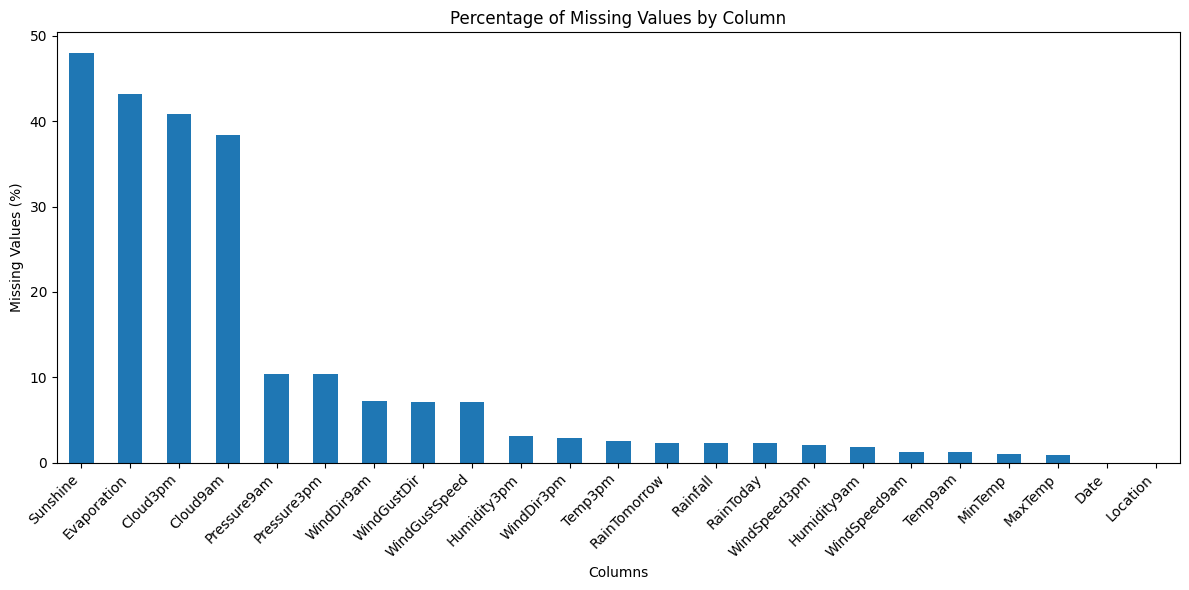


Missing Value Ratios:
Sunshine: 48.01%
Evaporation: 43.17%
Cloud3pm: 40.81%
Cloud9am: 38.42%
Pressure9am: 10.36%
Pressure3pm: 10.33%
WindDir9am: 7.26%
WindGustDir: 7.10%
WindGustSpeed: 7.06%
Humidity3pm: 3.10%
WindDir3pm: 2.91%
Temp3pm: 2.48%
RainTomorrow: 2.25%
Rainfall: 2.24%
RainToday: 2.24%
WindSpeed3pm: 2.11%
Humidity9am: 1.82%
WindSpeed9am: 1.21%
Temp9am: 1.21%
MinTemp: 1.02%
MaxTemp: 0.87%
Date: 0.00%
Location: 0.00%


In [53]:
# Calculate ratio of missing values for each column
total_rows = len(weather_input_df)
missing_ratios = (weather_input_df.isnull().sum() / total_rows) * 100

# Sort columns by missing ratio in descending order
missing_ratios_sorted = missing_ratios.sort_values(ascending=False)

# Plot missing value ratios
plt.figure(figsize=(12, 6))
missing_ratios_sorted.plot(kind='bar')
plt.title('Percentage of Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Missing Values (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nMissing Value Ratios:")
for col, ratio in missing_ratios_sorted.items():
    print(f"{col}: {ratio:.2f}%")

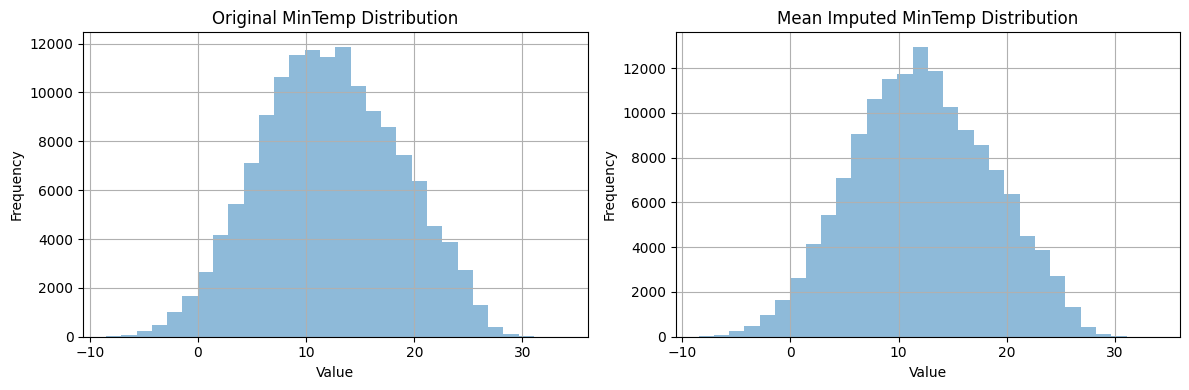

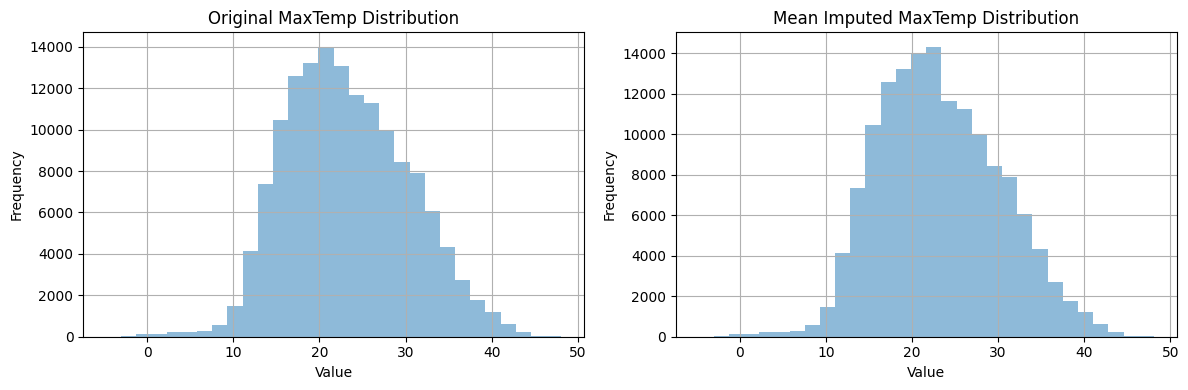

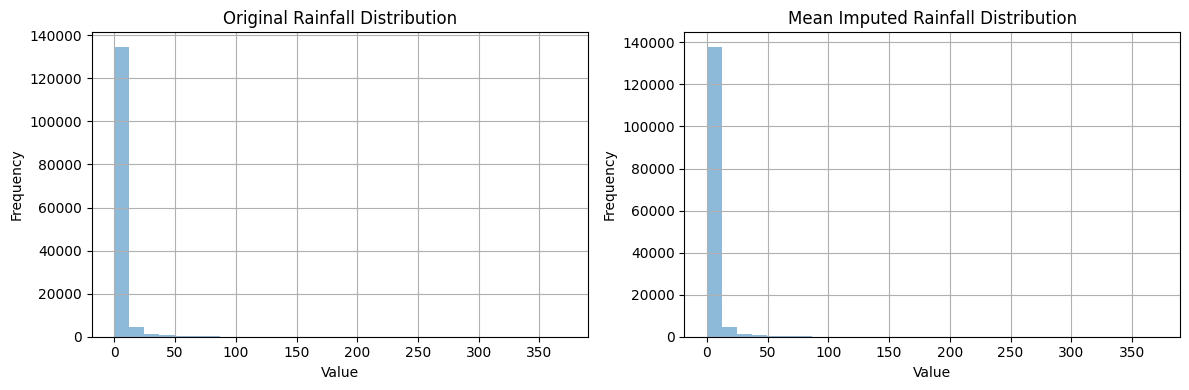

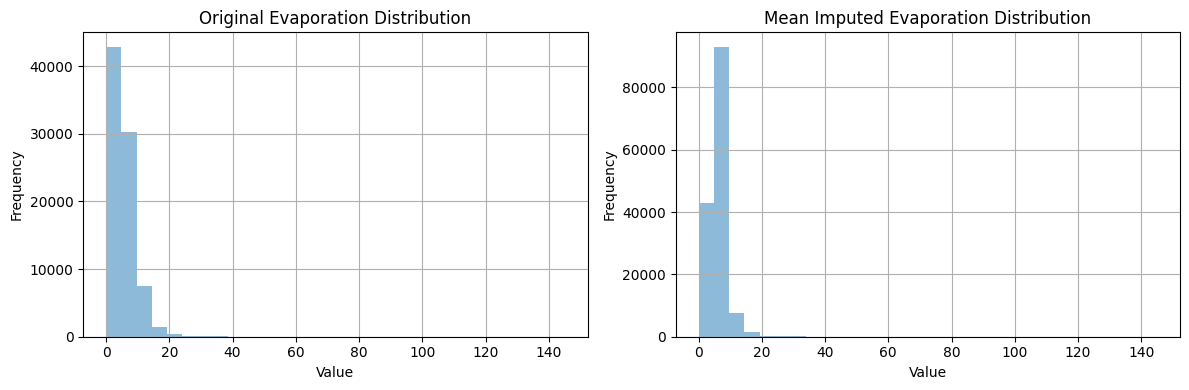

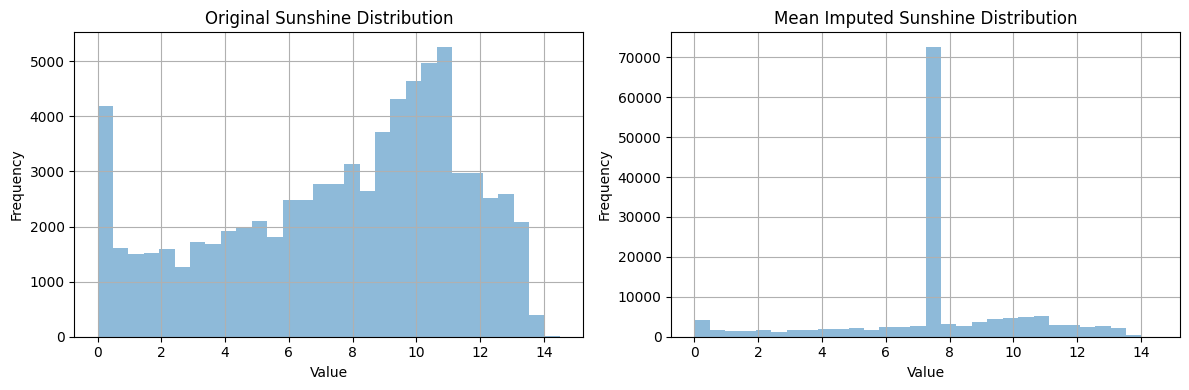

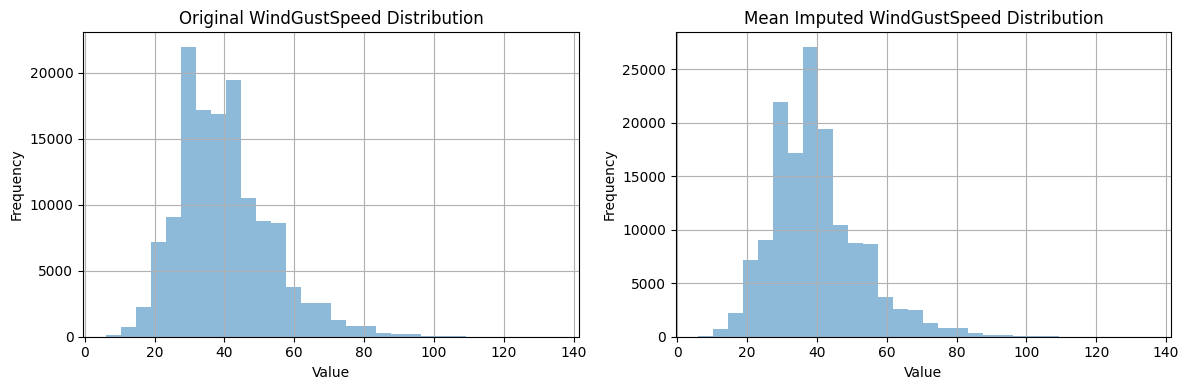

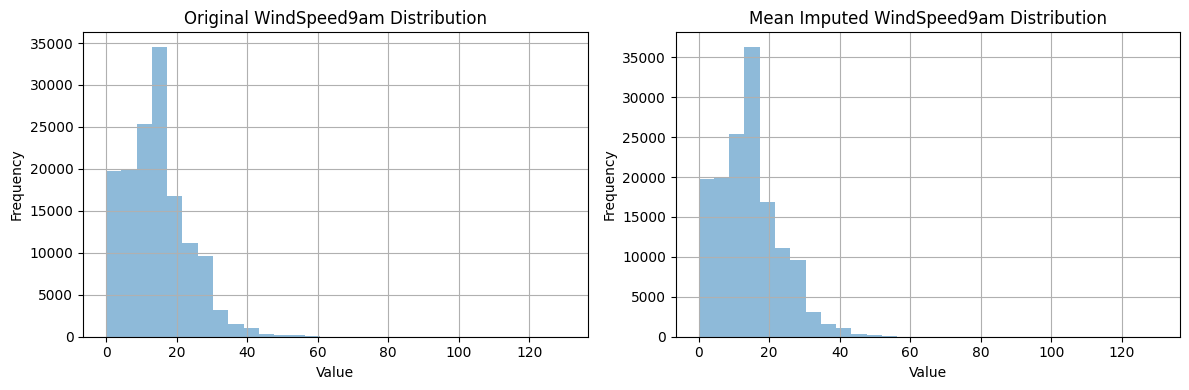

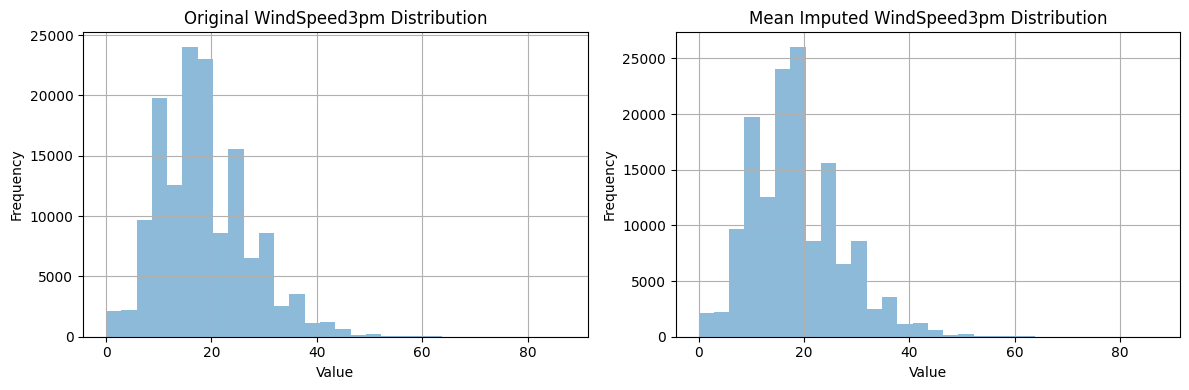

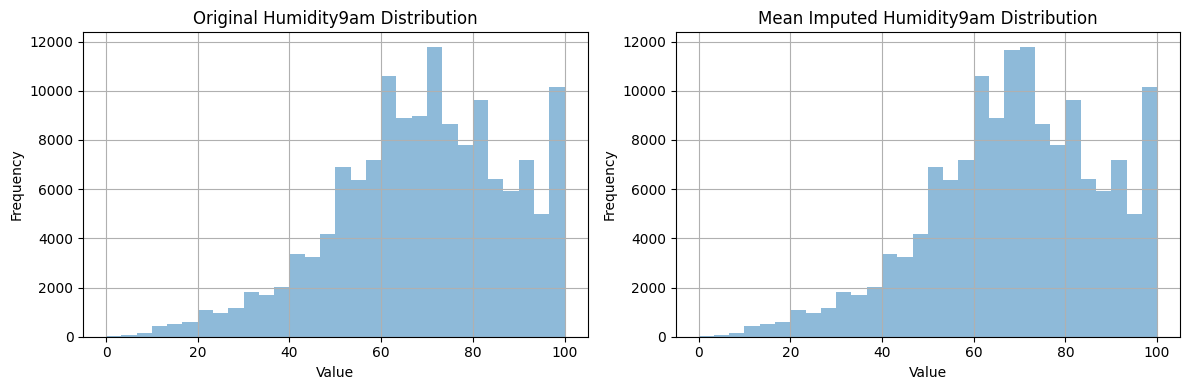

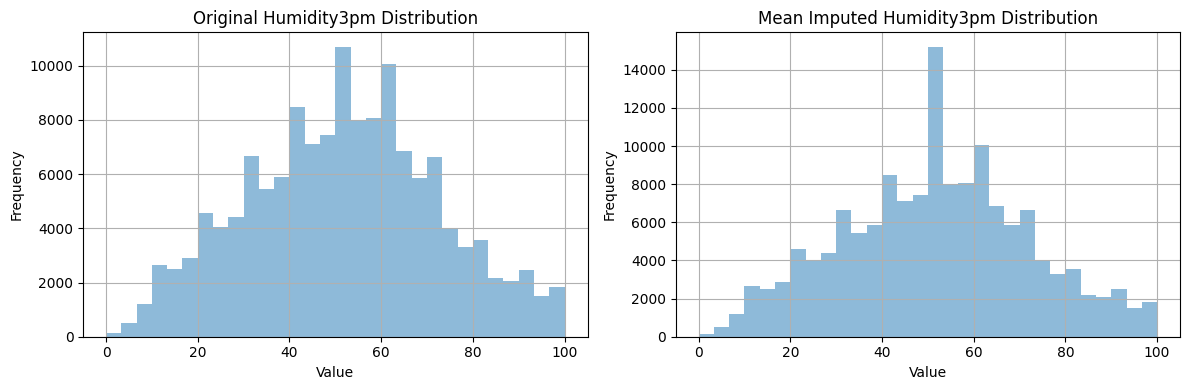

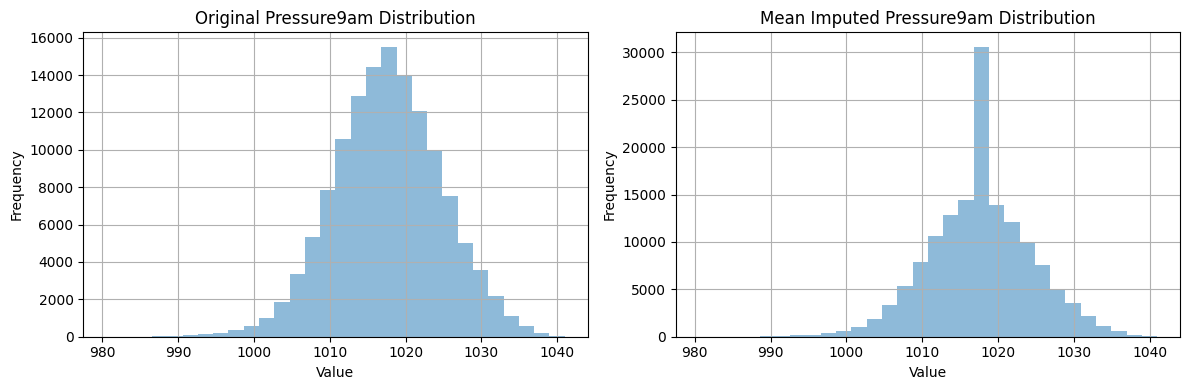

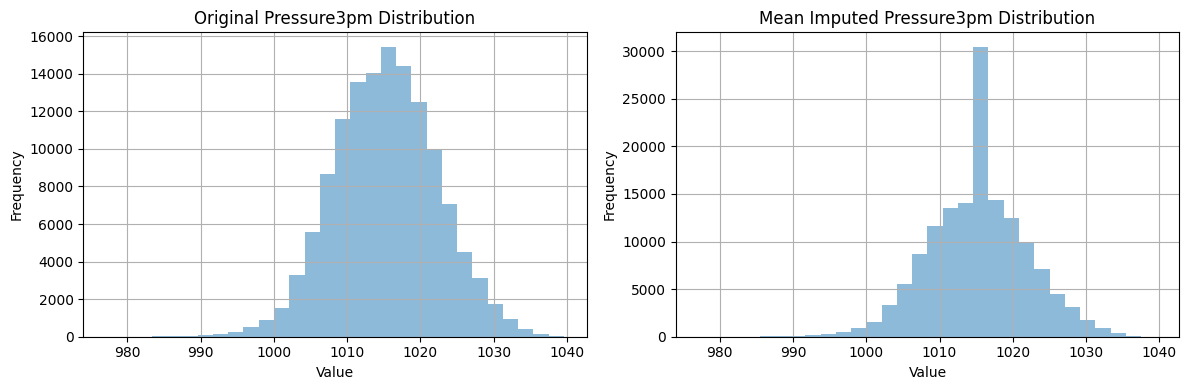

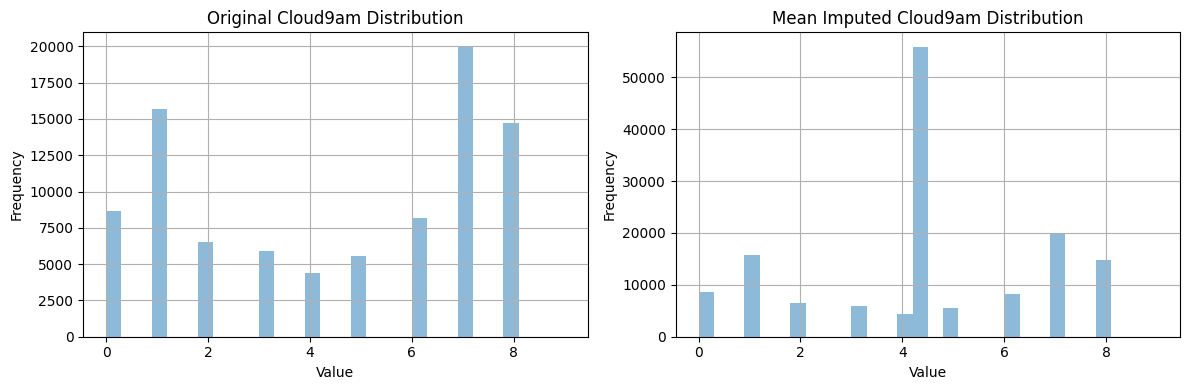

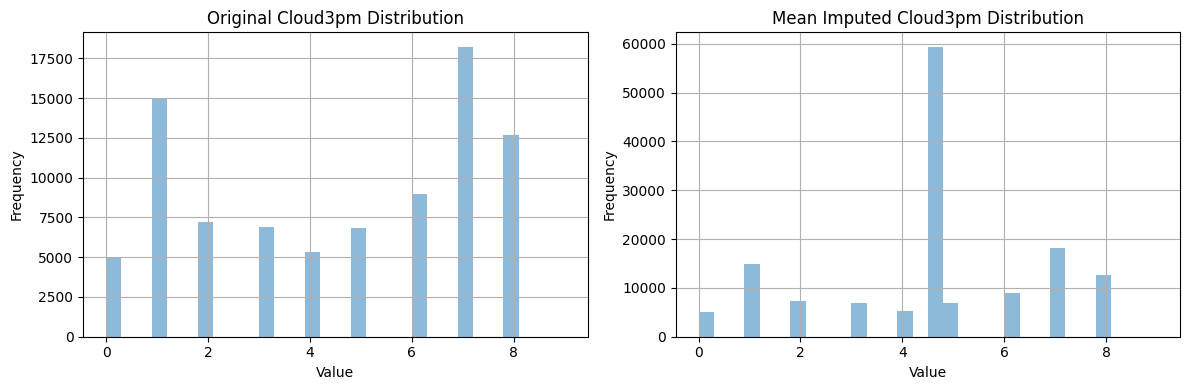

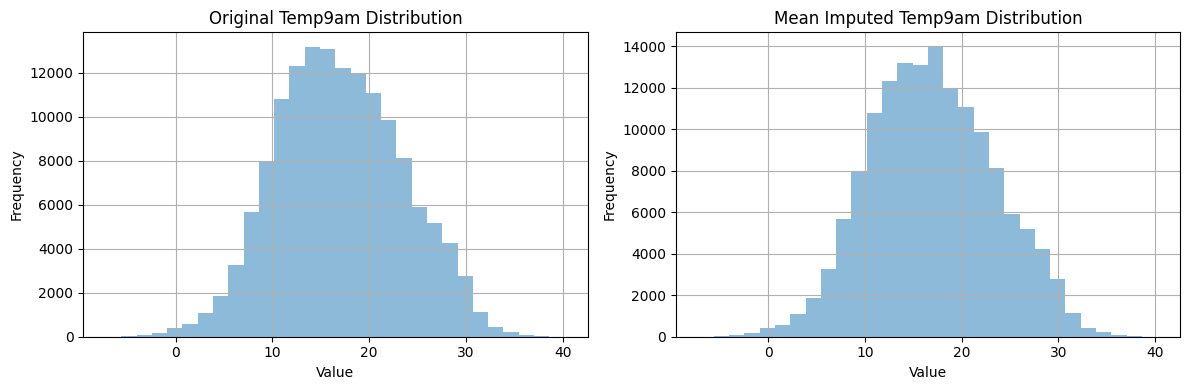

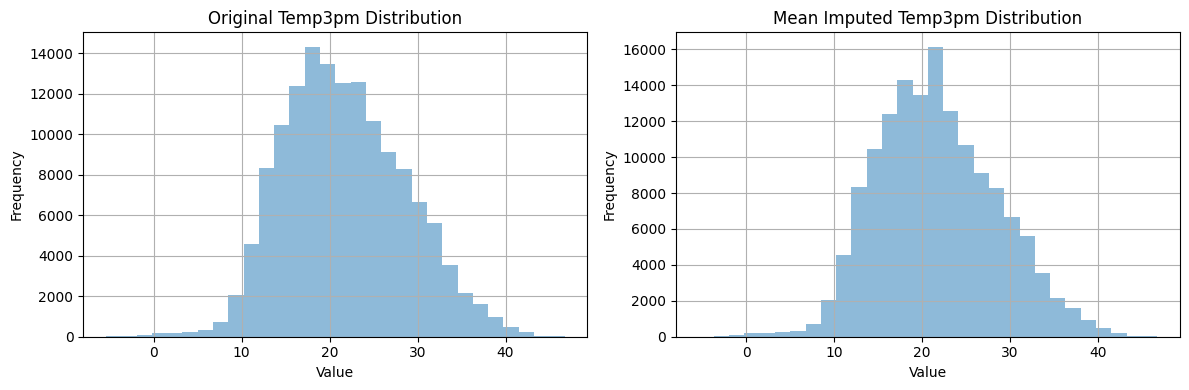

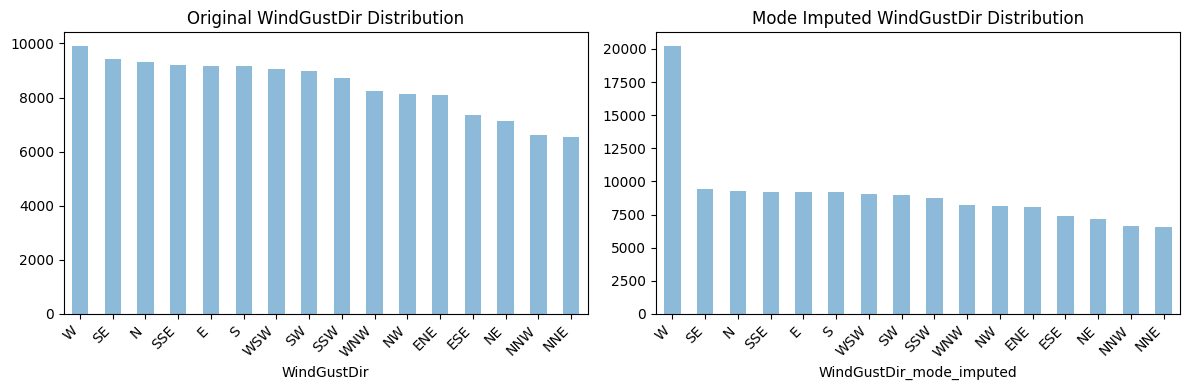

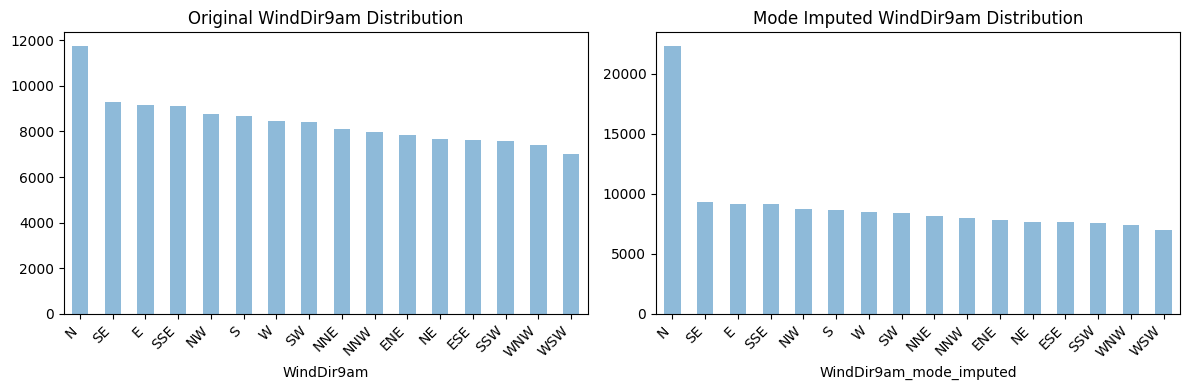

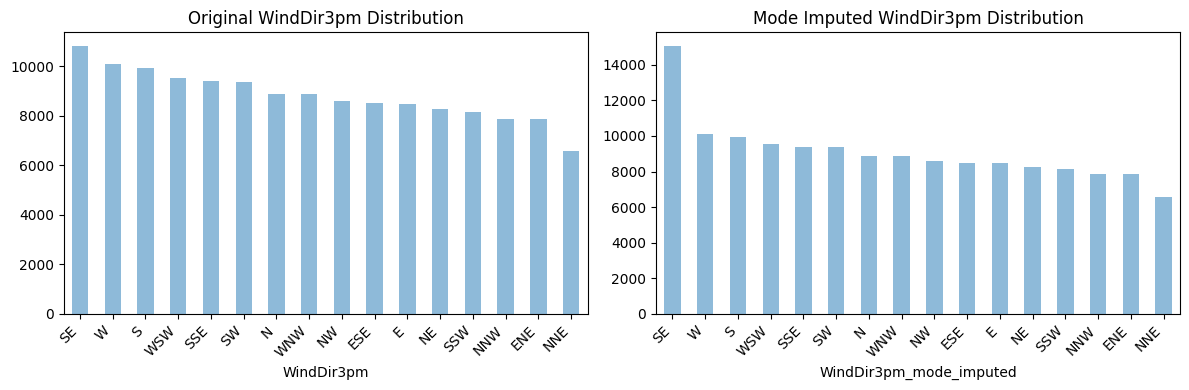

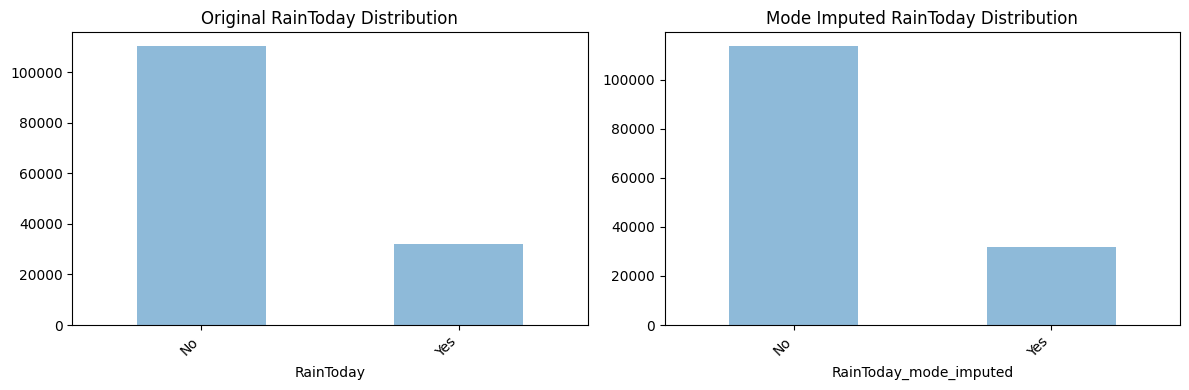

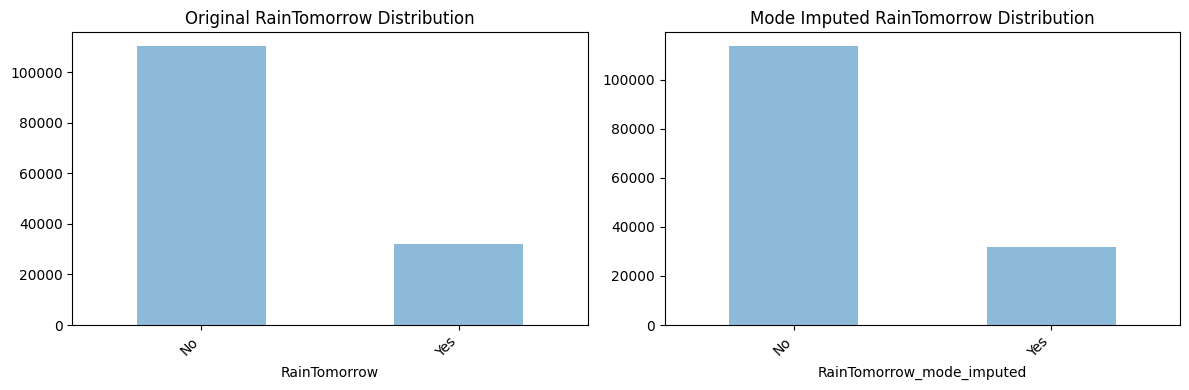


Summary of Imputation:

MinTemp:
Original missing values: 1485
After mean imputation: 0

MaxTemp:
Original missing values: 1261
After mean imputation: 0

Rainfall:
Original missing values: 3261
After mean imputation: 0

Evaporation:
Original missing values: 62790
After mean imputation: 0

Sunshine:
Original missing values: 69835
After mean imputation: 0

WindGustSpeed:
Original missing values: 10263
After mean imputation: 0

WindSpeed9am:
Original missing values: 1767
After mean imputation: 0

WindSpeed3pm:
Original missing values: 3062
After mean imputation: 0

Humidity9am:
Original missing values: 2654
After mean imputation: 0

Humidity3pm:
Original missing values: 4507
After mean imputation: 0

Pressure9am:
Original missing values: 15065
After mean imputation: 0

Pressure3pm:
Original missing values: 15028
After mean imputation: 0

Cloud9am:
Original missing values: 55888
After mean imputation: 0

Cloud3pm:
Original missing values: 59358
After mean imputation: 0

Temp9am:
Original 

In [54]:
# Create a copy of the dataframe for imputation
df_imputed = weather_input_df.copy()

# Separate numeric and categorical columns
numeric_columns = df_imputed.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df_imputed.select_dtypes(include=['object']).columns

# Impute numeric columns with mean
for col in numeric_columns:
    if df_imputed[col].isnull().any():
        mean_val = df_imputed[col].mean()
        df_imputed[f"{col}_mean_imputed"] = df_imputed[col].fillna(mean_val)
        
        # Plot original vs imputed for the first few numeric columns with missing values
        if df_imputed[col].isnull().sum() > 0:
            plt.figure(figsize=(12, 4))
            
            # Original data distribution
            plt.subplot(1, 2, 1)
            weather_input_df[col].hist(bins=30, alpha=0.5, label='Original')
            plt.title(f'Original {col} Distribution')
            plt.xlabel('Value')
            plt.ylabel('Frequency')
            
            # Imputed data distribution
            plt.subplot(1, 2, 2)
            df_imputed[f"{col}_mean_imputed"].hist(bins=30, alpha=0.5, label='Mean Imputed')
            plt.title(f'Mean Imputed {col} Distribution')
            plt.xlabel('Value')
            plt.ylabel('Frequency')
            
            plt.tight_layout()
            plt.show()

# Impute categorical columns with mode
for col in categorical_columns:
    if df_imputed[col].isnull().any():
        mode_val = df_imputed[col].mode()[0]
        df_imputed[f"{col}_mode_imputed"] = df_imputed[col].fillna(mode_val)
        
        # Plot original vs imputed for categorical columns
        plt.figure(figsize=(12, 4))
        
        # Original data distribution
        plt.subplot(1, 2, 1)
        weather_input_df[col].value_counts().plot(kind='bar', alpha=0.5)
        plt.title(f'Original {col} Distribution')
        plt.xticks(rotation=45, ha='right')
        
        # Imputed data distribution
        plt.subplot(1, 2, 2)
        df_imputed[f"{col}_mode_imputed"].value_counts().plot(kind='bar', alpha=0.5)
        plt.title(f'Mode Imputed {col} Distribution')
        plt.xticks(rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()

# Print summary of changes
print("\nSummary of Imputation:")
print("="*50)
for col in numeric_columns:
    if f"{col}_mean_imputed" in df_imputed.columns:
        print(f"\n{col}:")
        print(f"Original missing values: {weather_input_df[col].isnull().sum()}")
        print(f"After mean imputation: {df_imputed[f'{col}_mean_imputed'].isnull().sum()}")

for col in categorical_columns:
    if f"{col}_mode_imputed" in df_imputed.columns:
        print(f"\n{col}:")
        print(f"Original missing values: {weather_input_df[col].isnull().sum()}")
        print(f"After mode imputation: {df_imputed[f'{col}_mode_imputed'].isnull().sum()}")